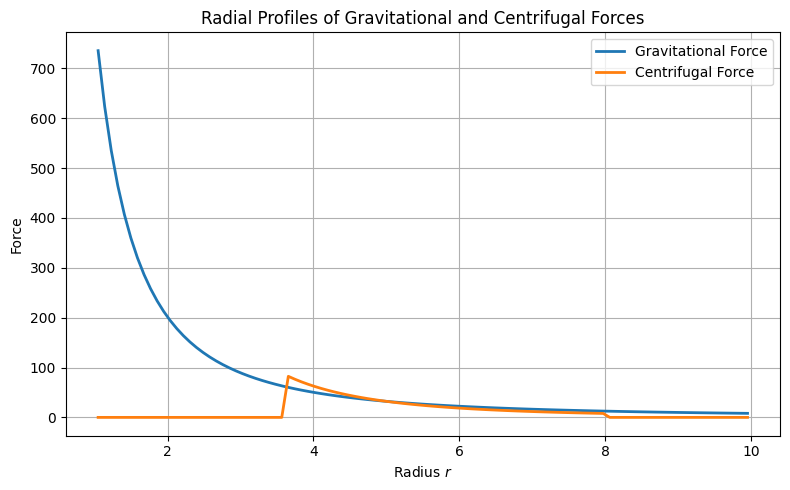

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Вказати шлях до .tab файлу
filename = "/home/etrevol/work/acc_disk/data/acc_disk.block0.out2.00000.tab"

# Пропуск першого рядка з метаданими і заголовка з іменами колонок
data = np.loadtxt(filename, comments="#")

# Розпакування колонок
r = data[:, 1]               # x1v: радіус
grav_force = data[:, 2]      # user_out_var0: сила тяжіння
centr_force = data[:, 3]     # user_out_var1: відцентрова сила

# Побудова графіку
plt.figure(figsize=(8, 5))
plt.plot(r, grav_force, label="Gravitational Force", lw=2)
plt.plot(r, centr_force, label="Centrifugal Force", lw=2)
plt.xlabel("Radius $r$")
plt.ylabel("Force")
plt.title("Radial Profiles of Gravitational and Centrifugal Forces")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

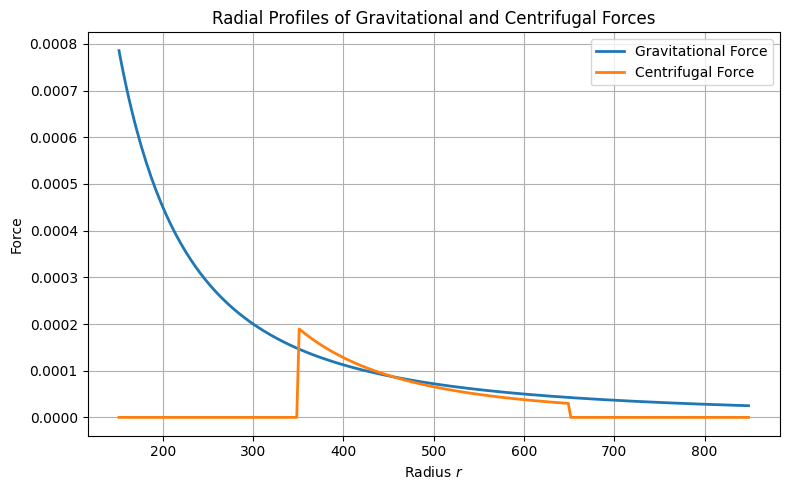

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Вказати шлях до .tab файлу
filename = "/home/etrevol/work/rotate_disk_new/data/bondi_disk.block0.out2.00000.tab"

# Пропуск першого рядка з метаданими і заголовка з іменами колонок
data = np.loadtxt(filename, comments="#")

# Розпакування колонок
r = data[:, 1]               # x1v: радіус
grav_force = data[:, 2]      # user_out_var0: сила тяжіння
centr_force = data[:, 3]     # user_out_var1: відцентрова сила

# Побудова графіку
plt.figure(figsize=(8, 5))
plt.plot(r, grav_force, label="Gravitational Force", lw=2)
plt.plot(r, centr_force, label="Centrifugal Force", lw=2)
plt.xlabel("Radius $r$")
plt.ylabel("Force")
plt.title("Radial Profiles of Gravitational and Centrifugal Forces")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Found 51 files.


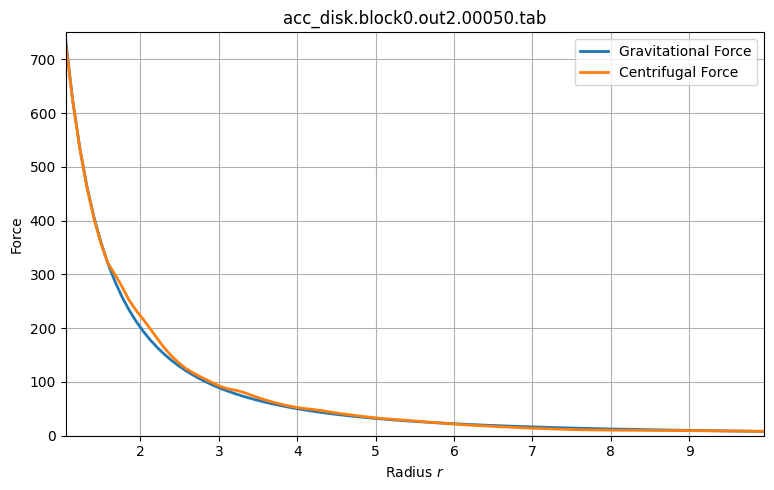

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import re

data_dir = "/home/etrevol/work/acc_disk_test_01/data"
output_dir = "/home/etrevol/work/acc_disk_test_01/plots/forces"
os.makedirs(output_dir, exist_ok=True)

anim_name = "force_animation"

file_pattern = "acc_disk.block0.out2"
all_files = sorted([
    os.path.join(data_dir, f)
    for f in os.listdir(data_dir)
    if re.match(rf"{file_pattern}\.\d{{5}}\.tab", f)
])

print(f"Found {len(all_files)} files.")

def read_tab_file(filepath):
    data = np.loadtxt(filepath, comments="#")
    r = data[:, 1]
    grav = data[:, 2]
    centr = data[:, 3]
    return r, grav, centr

fig, ax = plt.subplots(figsize=(8, 5))
line1, = ax.plot([], [], label='Gravitational Force', lw=2)
line2, = ax.plot([], [], label='Centrifugal Force', lw=2)
title = ax.set_title("Forces on Disk")
ax.set_xlabel("Radius $r$")
ax.set_ylabel("Force")
ax.grid(True)
ax.legend()
plt.tight_layout()

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    title.set_text("")
    return line1, line2, title

def update(frame):
    filepath = all_files[frame]
    r, grav, centr = read_tab_file(filepath)
    line1.set_data(r, grav)
    line2.set_data(r, centr)
    ax.set_xlim(r.min(), r.max())
    ax.set_ylim(0, 750)
    # ax.set_ylim(min(grav.min(), centr.min()), max(grav.max(), centr.max()))
    title.set_text(os.path.basename(filepath))
    return line1, line2, title

ani = animation.FuncAnimation(
    fig, update, frames=len(all_files),
    init_func=init, blit=False, interval=500
)

mp4_path = os.path.join(output_dir, anim_name + ".mp4")
ani.save(mp4_path, writer='ffmpeg', fps=5)

plt.show()

Found 101 files.


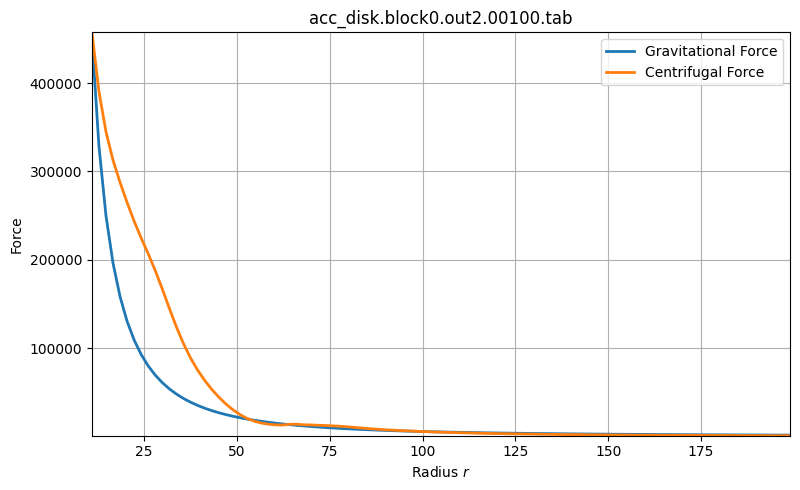

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import re

data_dir = "/home/etrevol/work/rotate_disk_test/data"
output_dir = "/home/etrevol/work/rotate_disk_test/plots/forces"
os.makedirs(output_dir, exist_ok=True)

anim_name = "force_animation"

file_pattern = "acc_disk.block0.out2"
all_files = sorted([
    os.path.join(data_dir, f)
    for f in os.listdir(data_dir)
    if re.match(rf"{file_pattern}\.\d{{5}}\.tab", f)
])

print(f"Found {len(all_files)} files.")

def read_tab_file(filepath):
    data = np.loadtxt(filepath, comments="#")
    r = data[:, 1]
    grav = data[:, 2]
    centr = data[:, 3]
    return r, grav, centr

fig, ax = plt.subplots(figsize=(8, 5))
line1, = ax.plot([], [], label='Gravitational Force', lw=2)
line2, = ax.plot([], [], label='Centrifugal Force', lw=2)
title = ax.set_title("Forces on Disk")
ax.set_xlabel("Radius $r$")
ax.set_ylabel("Force")
ax.grid(True)
ax.legend()
plt.tight_layout()

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    title.set_text("")
    return line1, line2, title

def update(frame):
    filepath = all_files[frame]
    r, grav, centr = read_tab_file(filepath)
    line1.set_data(r, grav)
    line2.set_data(r, centr)
    ax.set_xlim(r.min(), r.max())
    #ax.set_ylim(0, 2e6)
    ax.set_ylim(min(grav.min(), centr.min()), max(grav.max(), centr.max()))
    title.set_text(os.path.basename(filepath))
    return line1, line2, title

ani = animation.FuncAnimation(
    fig, update, frames=len(all_files),
    init_func=init, blit=False, interval=500
)

mp4_path = os.path.join(output_dir, anim_name + ".mp4")
ani.save(mp4_path, writer='ffmpeg', fps=5)

plt.show()

In [4]:
import numpy as np

# Вхідні параметри
r0 = 100.0     # положення максимуму тиску
c_ = 0.43     # безрозмірна константа

# Сума і добуток коренів
S = r0 / c_
P = r0**2 / (2.0 * c_)

# Розв’язання квадратного рівняння: x^2 - Sx + P = 0
discriminant = S**2 - 4 * P
if discriminant < 0:
    raise ValueError("Немає дійсних розв'язків для заданих r0 та c")

sqrt_discriminant = np.sqrt(discriminant)
r1 = 0.5 * (S - sqrt_discriminant)
r2 = 0.5 * (S + sqrt_discriminant)

# Виведення результатів
print(f"r1 = {r1:.6f}")
print(f"r2 = {r2:.6f}")


r1 = 72.771426
r2 = 159.786714


In [8]:
# Обчислення r0 та c з формул, які ти навів
import numpy as np

# Вхідні значення
r1 = 100.0
r2 = 1000.0

# Сума та добуток
S = r1 + r2
P = r1 * r2

# Формули
r0 = 2.0 * P / S
c = 2.0 * P / (S ** 2)

# Вивід
print(f"r0 = {r0:.6f}")
print(f"c  = {c:.6f}")

r0 = 181.818182
c  = 0.165289


In [ ]:
import numpy as np

G = 6.67430e-8         # гравітаційна стала, см^3 г^-1 с^-2
k_B = 1.380649e-16     # стала Больцмана, ерг/К
m_p = 1.6726219e-24    # маса протона, г

r = 100
M = 21.2 * 1.989e33           # маса чорної діри, г (масса Сонця)
l0 = 6.26e6              # характерна довжина в моделі, см
T = 1e5                # температура, К
mu = 1               # середня молекулярна маса

t_dyn = 2 * np.pi * np.sqrt((l0*r)**3 / (G * M))

v_s = np.sqrt(k_B * T / (mu * m_p))  # звукова швидкість
t_unit = l0 / v_s

t_tilde_dyn = t_dyn / t_unit

print(f"Звукова швидкість: v_s = {v_s:.2e} см/с")
print(f"Фізичний динамічний час: t_dyn = {t_dyn:.2e} с")
print(f"Одиниця часу Athena++: t_unit = {t_unit:.2e} с")
print(f"Безрозмірний динамічний час: t̃_dyn = {t_tilde_dyn:.2e}")

Звукова швидкість: v_s = 2.87e+06 см/с
Фізичний динамічний час: t_dyn = 1.86e+00 с
Одиниця часу Athena++: t_unit = 2.18e+00 с
Безрозмірний динамічний час: t̃_dyn = 8.51e-01
